In [2]:
import pandas as pd
import numpy as np

file = "DF_FINAL.xlsx"
df_final = pd.read_excel(file)

df_final["timestamp"] = pd.to_datetime(
    df_final["timestamp"],
    dayfirst=True,
    errors="coerce"
)

# Extraer fecha, día de semana y hora
df_final["fecha"] = df_final["timestamp"].dt.date
df_final["dia_semana"] = df_final["timestamp"].dt.day_name(locale="es_ES")  # nombres en español
df_final["hora"] = df_final["timestamp"].dt.hour

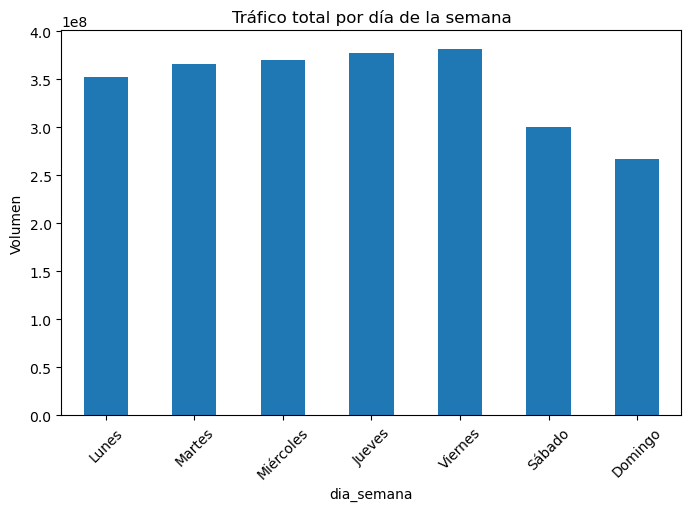

In [3]:
import matplotlib.pyplot as plt

#trafico_semana = df_final.drop(columns=["timestamp", "fecha", "hora", "dia_semana"]).sum(axis=1).groupby(df_final["dia_semana"]).sum()

# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Calcular tráfico total por día de la semana
trafico_semana = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["dia_semana"])
    .sum()
)
trafico_semana = trafico_semana.reindex(["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"])

trafico_semana.plot(kind="bar", figsize=(8,5))
plt.title("Tráfico total por día de la semana")
plt.ylabel("Volumen")
plt.xticks(rotation=45)
plt.show()

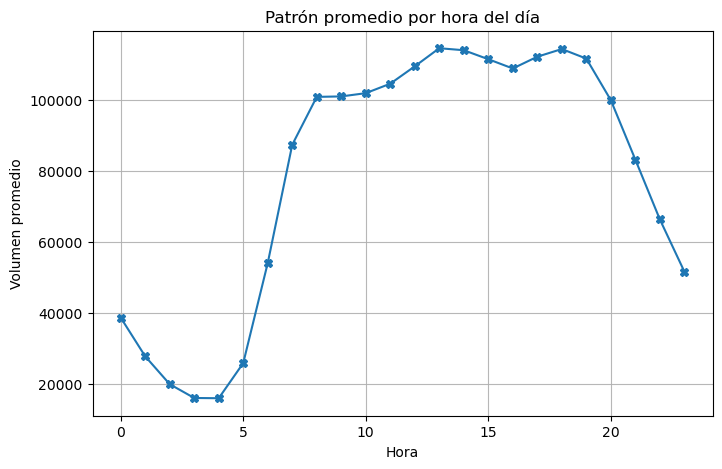

In [4]:
# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

trafico_hora = df_final.drop(columns=columnas_excluir).sum(axis=1).groupby(df_final["hora"]).mean()

trafico_hora.plot(kind="line", marker="X", figsize=(8,5))
plt.title("Patrón promedio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Volumen promedio")
plt.grid(True, linestyle="-", alpha=0.91)
plt.show()

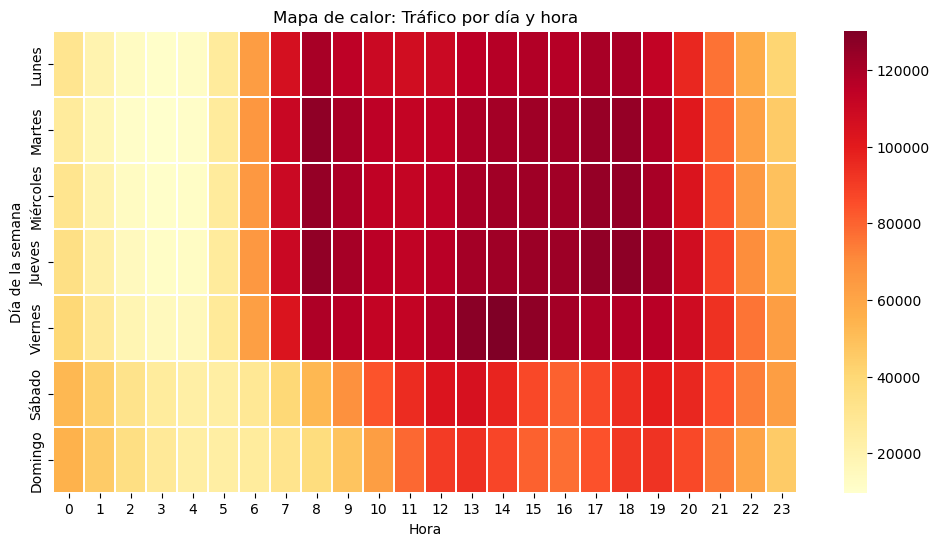

In [5]:
import seaborn as sns

# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

trafico_dia_hora = df_final.drop(columns=columnas_excluir).sum(axis=1)
pivot = pd.DataFrame({
    "hora": df_final["hora"],
    "dia_semana": df_final["dia_semana"],
    "trafico": trafico_dia_hora
})
tabla = pivot.groupby(["dia_semana","hora"]).mean().reset_index()
# Reordenar días
dias_orden = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
tabla["dia_semana"] = pd.Categorical(tabla["dia_semana"], categories=dias_orden, ordered=True)

heatmap_data = tabla.pivot(index="dia_semana", columns="hora", values="trafico")
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, annot=False)
plt.title("Mapa de calor: Tráfico por día y hora")
plt.ylabel("Día de la semana")
plt.xlabel("Hora")
plt.show()

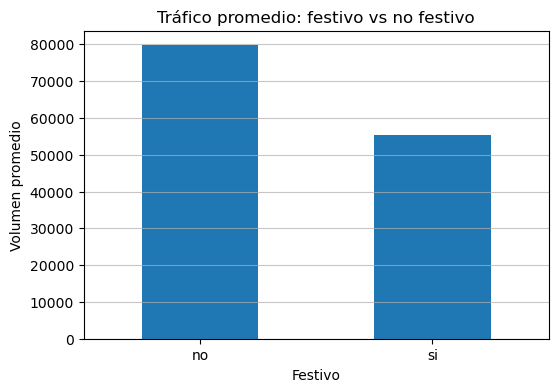

In [6]:
import matplotlib.pyplot as plt

# 1. Columnas a excluir 
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Columnas AEMET
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Sumar tráfico total por fila y agrupar por festivo / no festivo
trafico_festivo = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["festivo"])
    .mean()
)

# 5. Gráfico de barras
trafico_festivo.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Tráfico promedio: festivo vs no festivo")
plt.xlabel("Festivo")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.show()


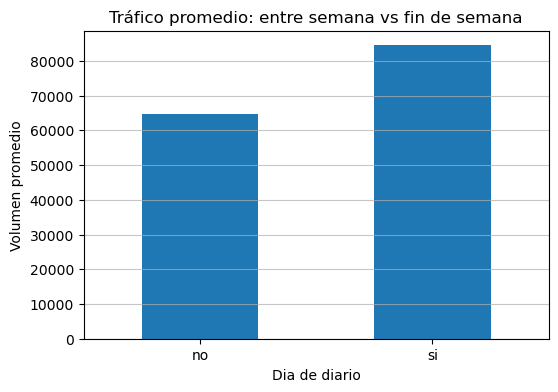

In [7]:
import matplotlib.pyplot as plt

# 1. Columnas a excluir 
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Columnas AEMET
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Sumar tráfico total por fila y agrupar por festivo / no festivo
trafico_festivo = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["entre semana"])
    .mean()
)

# 5. Gráfico de barras
trafico_festivo.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Tráfico promedio: entre semana vs fin de semana")
plt.xlabel("Dia de diario")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="-", alpha=0.7)
plt.show()


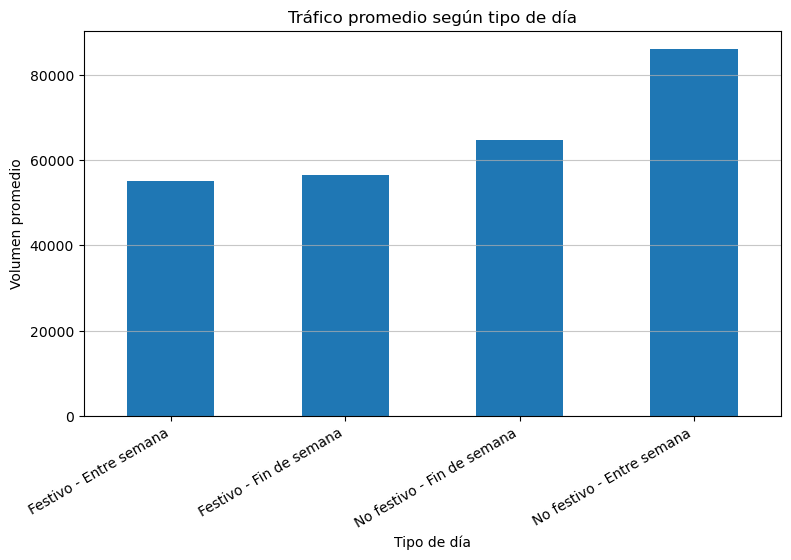

In [8]:
df_final["tipo_dia"] = (
    df_final["festivo"].map({"si": "Festivo", "no": "No festivo"})
    + " - " +
    df_final["entre semana"].map({"si": "Entre semana", "no": "Fin de semana"})
)

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "tipo_dia"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# Tráfico promedio por tipo de día
trafico_tipo_dia = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["tipo_dia"])
    .mean()
    .sort_values()
)

trafico_tipo_dia.plot(kind="bar", figsize=(9,5))
plt.title("Tráfico promedio según tipo de día")
plt.xlabel("Tipo de día")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.7)
plt.show()


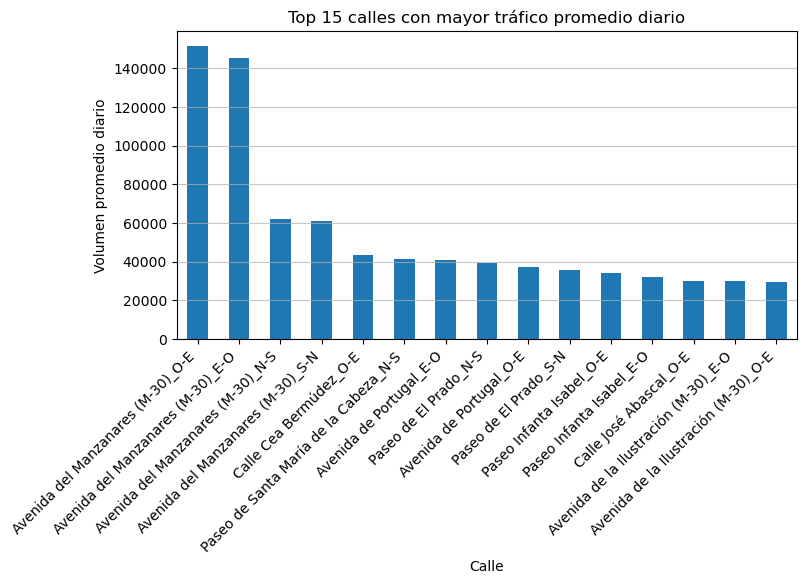

In [11]:
columnas_trafico = [
    col for col in df_final.columns
    if col not in columnas_excluir
]

trafico_diario = (
    df_final
    .groupby("fecha")[columnas_trafico]
    .sum()
)

trafico_medio_calle = trafico_diario.mean()

top_15 = trafico_medio_calle.sort_values(ascending=False).head(15)

top_15.plot(kind="bar", figsize=(8,4))
plt.title("Top 15 calles con mayor tráfico promedio diario")
plt.xlabel("Calle")
plt.ylabel("Volumen promedio diario")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.7)
plt.show()


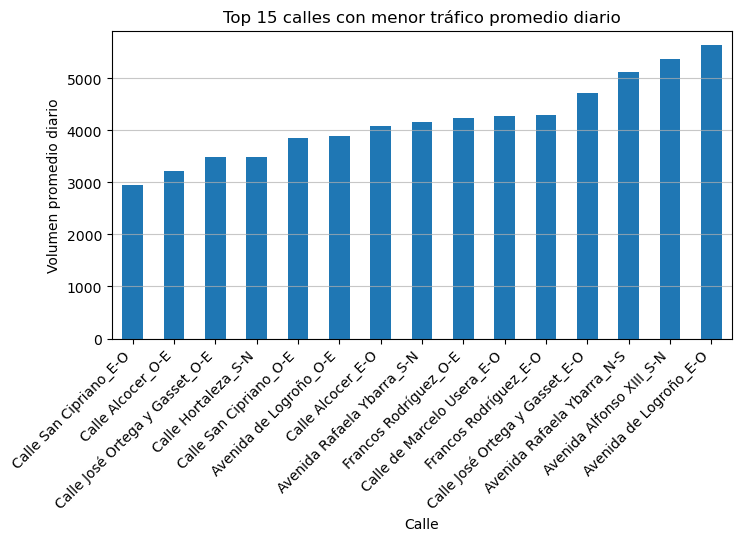

In [12]:
bottom_15 = trafico_medio_calle.sort_values(ascending=True).head(15)

bottom_15.plot(kind="bar", figsize=(8,4))
plt.title("Top 15 calles con menor tráfico promedio diario")
plt.xlabel("Calle")
plt.ylabel("Volumen promedio diario")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.7)
plt.show()

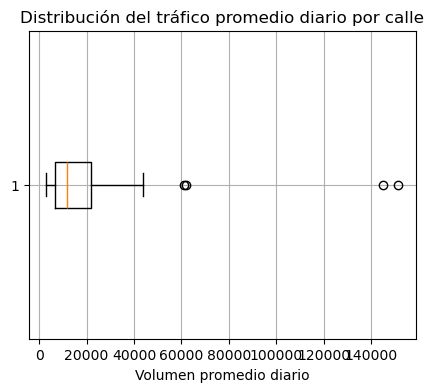

In [13]:
plt.figure(figsize=(5,4))
plt.boxplot(trafico_medio_calle.values, vert=False)
plt.title("Distribución del tráfico promedio diario por calle")
plt.xlabel("Volumen promedio diario")
plt.grid(True)
plt.show()


In [14]:
Q1 = trafico_medio_calle.quantile(0.25)
mediana = trafico_medio_calle.quantile(0.50)
Q3 = trafico_medio_calle.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = trafico_medio_calle[
    (trafico_medio_calle < limite_inferior) |
    (trafico_medio_calle > limite_superior)
]

outliers.sort_values(ascending=False).head(5)

resumen_boxplot = {
    "Q1": Q1,
    "Mediana": mediana,
    "Q3": Q3,
    "IQR": IQR,
    "Límite inferior": limite_inferior,
    "Límite superior": limite_superior,
    "Nº de calles": len(trafico_medio_calle),
    "Nº de outliers": len(outliers)
}

for k, v in resumen_boxplot.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")


Q1: 6811.74
Mediana: 11594.96
Q3: 22042.77
IQR: 15231.04
Límite inferior: -16034.82
Límite superior: 44889.33
Nº de calles: 104
Nº de outliers: 4


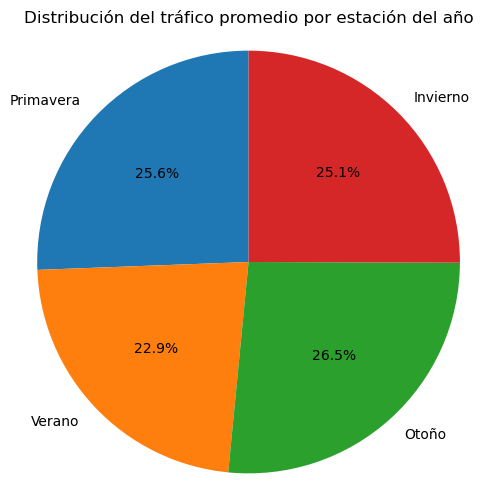

In [19]:
def asignar_estacion(fecha):
    dia = fecha.day
    mes = fecha.month

    if (mes == 3 and dia >= 20) or (mes in [4, 5]) or (mes == 6 and dia < 21):
        return "Primavera"
    elif (mes == 6 and dia >= 21) or (mes in [7, 8]) or (mes == 9 and dia < 22):
        return "Verano"
    elif (mes == 9 and dia >= 22) or (mes in [10, 11]) or (mes == 12 and dia < 21):
        return "Otoño"
    else:
        # Invierno: del 21 de diciembre al 20 de marzo
        return "Invierno"

df_final["estacion"] = df_final["fecha"].apply(asignar_estacion)

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "estacion"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

columnas_trafico = [
    col for col in df_final.select_dtypes(include="number").columns
    if col not in ["hora"]
]

df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

trafico_estacion = (
    df_final
    .groupby("estacion")["trafico_total"]
    .mean()
    .reindex(["Primavera", "Verano", "Otoño", "Invierno"])
)

plt.figure(figsize=(6,6))
plt.pie(
    trafico_estacion,
    labels=trafico_estacion.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Distribución del tráfico promedio por estación del año")
plt.axis("equal")  # para que sea circular
plt.show()


Intercepto (β0): 159462.59
Coeficiente precipitación (β1): 74.09
R² del modelo: 0.000


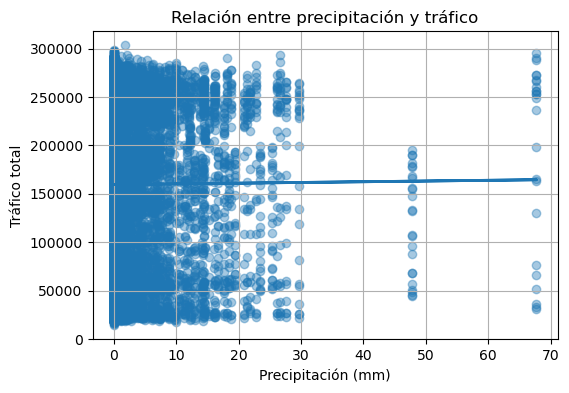

In [20]:
df_final["precipitacion"] = df_final["AEMET_prec"]

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "precipitacion"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

columnas_trafico = [
    col for col in df_final.select_dtypes(include="number").columns
    if col not in ["hora", "AEMET_prec"]
]

df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

df_reg = df_final[["trafico_total", "precipitacion"]].dropna()

from sklearn.linear_model import LinearRegression
import numpy as np

X = df_reg[["precipitacion"]]   # debe ser 2D
y = df_reg["trafico_total"]

modelo = LinearRegression()
modelo.fit(X, y)

beta_0 = modelo.intercept_
beta_1 = modelo.coef_[0]

print(f"Intercepto (β0): {beta_0:.2f}")
print(f"Coeficiente precipitación (β1): {beta_1:.2f}")

r2 = modelo.score(X, y)
print(f"R² del modelo: {r2:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.4)
plt.plot(X, modelo.predict(X), linewidth=2)
plt.xlabel("Precipitación (mm)")
plt.ylabel("Tráfico total")
plt.title("Relación entre precipitación y tráfico")
plt.grid(True)
plt.show()